<a href="https://colab.research.google.com/github/kalex066/ML-2Examen/blob/main/BankMarketingUCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicción de Clientes que suscriben un deposito a plazo**

**Objetivo:** Evaluar la capacidad del estudiante para limpiar, explorar, implementar y evaluar modelos de clasificación en un dataset de clientes bancarios. Los estudiantes deben demostrar habilidades prácticas en la manipulación de datos, creación de visualizaciones y modelado predictivo.

**Descripción del Dataset**:El https://archive.ics.uci.edu/dataset/222/bank+marketing contiene datos relacionados con campañas de marketing directo (llamadas telefónicas) de una institución bancaria portuguesa. La tarea es predecir si el cliente suscribirá un depósito a plazo (variable y).


| Columna | Descripción |
| :--- | :--- |
| **`age`** | Edad del cliente |
| **`job`** | Tipo de trabajo del cliente.|
| **`marital`** | Estado civil del cliente. |
| **`education`** |Nivel educativo del cliente.|
| **`default`** | ¿Tiene crédito en incumplimiento?|
| **`balance`** |  Balance promedio anual|
| **`housing`** | ¿Tiene préstamo de vivienda?|
| **`loan`** | ¿Tiene préstamo personal?|
| **`contact`** | Tipo de contacto de comunicación. |
| **`day`** | Último día de contacto del mes |
| **`month`** | Último mes de contacto del año.|
| **`duration`** | Duración de la última llamada de contacto, en segundos.|
| **`campaign`** | Número de contactos realizados durante esta campaña. |
| **`pdays`** | Número de días desde el último contacto de una campaña anterior|
| **`previous`** |  Número de contactos realizados antes de esta campaña. |
| **`poutcome`** | Resultado de la campaña de marketing anterior. |
| **`y`** | ¿Se suscribió el cliente a un depósito a plazo? (Variable objetivo) |


# <font color='1890A3'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

>## <font color='1890A3'>**Paso 1.1 Configuracion e importaciones** </font>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


> ## <font color='1890A3'>**Paso 1.2 Cargar el dataset**</font>

El enunciado del examen pide implementar SVM (Support Vector Machine), que es un algoritmo computacionalmente costoso que escala mal con datasets grandes porque el tiempo de entrenamiento crece de forma cuadrática o cúbica con el número de muestras.

En la documentacion del dataset dice: "the smallest datasets are provided to test more computationally demanding machine learning algorithms (e.g., SVM)". Por eso se trabajara con el archivo **bank.csv** el cual tiene 4521 filas y las 17 columnas indicadas en el diccionario de datos del enunciado, a diferencia de los archivos que estan en la carpeta bank-additional que tienen 4 columnas extra que no se mencionan en el enunciado.

**Nota:** Todo lo referente al modelo SVM se consulta en la documentacion de scikit-learn y con llm's.

In [2]:
df = pd.read_csv('/content/sample_data/bank.csv')

print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 4521 filas x 1 columnas
Memoria aproximada: 663 KB

Columnas: ['age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"']


Las columnas no estan separadas por comas sino por punto y coma, se especifica el separador para tener las 17 columnas

In [3]:
df = pd.read_csv('/content/sample_data/bank.csv', sep=";")

print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 4521 filas x 17 columnas
Memoria aproximada: 2637 KB

Columnas: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


> ## <font color='1890A3'>**Paso 1.3 Primeras y Ultimas filas del Dataset**</font>

In [4]:
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())

=== Primeras 5 filas ===


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no



=== Ultimas 5 filas ===


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no


`pdays` aparece en la mayoría de las filas con un valore de -1, asummo que significa que el cliente no fue contactado en una campaña de marketing anterior.

`poutcome` igual con varios valores "unknown", relacionado con el -1 de `pdays`, si el cliente no fue contactado antes pues no hay resultado de la campaña anterior.

`contact` tambien aparece con valores "unknown" , supongo que no se registro el numero telefonico de contacto.

`balance` tiene valores negativos, es decir, clientes con deudas en sus cuentas.

`y` con valor de "no" esta en las 10 filas visibles, al parecer la mayoria de los clientes no contrato un deposito a plazo, es posible que las clases esten desbalanceadas.

> ## <font color='1890A3'>**Paso 1.4 Estructura General del Dataset**</font>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


Aparentemente el dataset no tiene nulos

> ## <font color='1890A3'>**Paso 1.5 Estadisticas Descriptivas del Dataset**</font>

In [6]:
df.describe()
print('=== Columnas numericas ===')
display(df.describe())
print('=== Columnas categoricas ===')
display(df.describe(include='object'))


=== Columnas numericas ===


,age,balance,day,duration,campaign,pdays,previous
count,4521.0000,4521.0000,4521.0000,4521.0000,4521.0000,4521.0000,4521.0000
mean,41.1701,1422.6578,15.9153,263.9613,2.7936,39.7666,0.5426
std,10.5762,3009.6381,8.2477,259.8566,3.1098,100.1211,1.6936
min,19.0000,-3313.0000,1.0000,4.0000,1.0000,-1.0000,0.0000
25%,33.0000,69.0000,9.0000,104.0000,1.0000,-1.0000,0.0000
50%,39.0000,444.0000,16.0000,185.0000,2.0000,-1.0000,0.0000
75%,49.0000,1480.0000,21.0000,329.0000,3.0000,-1.0000,0.0000
max,87.0000,71188.0000,31.0000,3025.0000,50.0000,871.0000,25.0000


=== Columnas categoricas ===


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


**Categoricas:**

`job` tiene 12 categorías únicas, siendo manangment la más frecuente es management (969).

`marital` con 3 categorías (married, single, divorced) y con "married" como el valor mas frecuente.

`education` tiene 4 categorías con "secondary" como la mas frecuente, Esta variable tiene orden (primary < secondary < tertiary) -> candidata a OrdinalEncoder.

`default` con 2 categorías (yes/no) y "no" dominando casi todo el dataset (4.445 de 4.521)

`housing` tambien con 2 categorías (yes/no), yes es mayoría con 2.559 registros -> categorias balanceadas.

`loan` con 2 categorías (yes/no) y "no" como mas frecuente con 3.830 registros.

`contact` tiene 3 categorías, y "cellular" es la más frecuente (2.896) registros.

`month` perfecto con 12 categorías únicas (meses del año), con "may" siendo el mas frecuente con 1.398 registros.
También tiene orden natural pero no es lineal -> One hot Encoder.

`poutcome` con 4 categorías, pero unknown es el valor más frecuente con 3.705 de 4.521, la mayoria de los clientes no fue contactado en ninguna campaña anterior. Se puede considerar unknown como una categoria o imputar.

`y ` target binario, con "no" con 4.000 registros. El dataset esta desbalanceado hacia el no (clientes que no pusieron un deposito a plazos).

**Numericas:**

`age` con rango de 19 a 87 años, con media de 41.

`balance` con valores extremos, con minimos negativos (-3.313) y maximo de (71.188). El 75% de los clientes tiene balance menor a 1.480.

`duration` tiene media de 263 s ( aprox 4 min) y máximo de 3.025 s(aprox 50 min).

`campaign`, con media de 2.79 contactos pero máximo de 50. El 75% de los clientes fue contactado 3 veces o menos, pero alguien fue contactado 50 veces en la misma campaña, lo que indica presencia de outliers.

`pdays` la media es de 39.7 pero el 75% tiene valor -1 (no fue contactado antes).

`previous`, la media es de 0.54 y el 75% tiene valor 0 (la gran mayoría nunca fue contactado antes) con un valor máximo de 25 (es un outlier)



# <font color='1890A3'>**SECCION 2. LIMPIEZA DE DATOS**
**tipos | duplicados | inconsistencias | nulos | outliers** </font>

> ## <font color='1890A3'>**Paso 2.1 Verificar y corregir tipos de datos**</font>

In [7]:
print('Tipos de Datos ANTES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos ANTES de limpiar:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object



Voy a convertir las variables con categorias yes/no a binarias, yes=1 y no=0.
El resto de los cambios se realizara en el preprocesamiento


In [8]:
binary_cols = ['y', 'default', 'housing', 'loan']
df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))

print("Tipos después de conversión:")
print(df[binary_cols].dtypes)
print()
print("Distribución de y (target):")
print(df['y'].value_counts())

Tipos después de conversión:
y          int64
default    int64
housing    int64
loan       int64
dtype: object

Distribución de y (target):
y
0    4000
1     521
Name: count, dtype: int64


Se confirma el desbalance del target!!

In [9]:
print('Tipos de Datos DESPUES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos DESPUES de limpiar:
age           int64
job          object
marital      object
education    object
default       int64
balance       int64
housing       int64
loan          int64
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object



> ## <font color='1890A3'>**Paso 2.2 Identificar consistencias en variables categoricas**</font>

In [10]:
# TrabajO en una copia del dataset
df_clean = df.copy()

# Verificar valores únicos en columnas categóricas
cols_cat = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

for col in cols_cat:
    valores_unicos = df_clean[col].unique()
    print(f"• Columna '{col}' ({len(valores_unicos)} categorías únicas):")
    print(f"   -> {sorted(valores_unicos)}\n")


• Columna 'job' (12 categorías únicas):
   -> ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

• Columna 'marital' (3 categorías únicas):
   -> ['divorced', 'married', 'single']

• Columna 'education' (4 categorías únicas):
   -> ['primary', 'secondary', 'tertiary', 'unknown']

• Columna 'contact' (3 categorías únicas):
   -> ['cellular', 'telephone', 'unknown']

• Columna 'month' (12 categorías únicas):
   -> ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

• Columna 'poutcome' (4 categorías únicas):
   -> ['failure', 'other', 'success', 'unknown']



En las colummas `job`, `education`, `contact` se observa la categoria "unknown", que son nulos digamos disfrazados. Hay que reemplazarlos con Nan para tratarlos mas adelante.

La columna `poutcome` tambien tiene 'unknown" pero se dejara como una categoria valida, porque en este caso significa que el cliente no fue contactado en campanas anteriores y es un valor valido y una categoria a considerar.

In [11]:
cols_unknown = ['job', 'education', 'contact']
df_clean[cols_unknown] = df_clean[cols_unknown].replace('unknown', np.nan)

#nulos generados
print("Nulos después del reemplazo:")
print(df_clean[cols_unknown].isnull().sum())

Nulos después del reemplazo:
job            38
education     187
contact      1324
dtype: int64


> ## <font color='1890A3'>**Paso 2.3 Identificar y eliminar duplicados**</font>

In [12]:
n_total = len(df_clean)
n_dupes = df_clean.duplicated().sum()

if n_dupes > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Filas después de eliminar duplicados: {len(df_clean)}')
else:
    print('No hay duplicados. No se eliminó ninguna fila.')

No hay duplicados. No se eliminó ninguna fila.


> ## <font color='1890A3'>**Paso 2.4 Analisis de valores nulos**</font>

In [13]:
null_report = pd.DataFrame({
    'Nulos':      df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2),
    'Tipo':       df_clean.dtypes
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)
print(f"Valores nulos en el dataset: {df_clean.isnull().sum().sum()}")

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Tipo,Umbral
contact,1324,29.2900,object,Imputar (< 30%)
education,187,4.1400,object,Imputar (< 30%)
job,38,0.8400,object,Imputar (< 30%)


Valores nulos en el dataset: 1549


##**Imputacion de columnas categoricas**

|**Columna**|**Nulos**|**Porcentaje %**|**Estrategia de imputacion**|
|:---|:---|:---|:---|
|`contact`|1324|29.29%|Moda, el valor mas frecuente es "cellular" que es el medio de contacto mas comun en los ultimos tiempos y ha desplazdo el uso de telefonos fijos|
|`education`|187|4.14%|Moda, el valor mas frecuente es 'secondary' que clínicamente representa el caso intermedio, minimizando el sesgo|
|`job`|38|0.84 %|Moda, los nulos son menores al 10% y la moda es una de bajo impacto|


In [14]:
#imputacion de variables categoricas con moda
cols_nulscat = ['contact', 'education', 'job']
resultados_nuloscat = []

for col in cols_nulscat:
    nulos_antes = df_clean[col].isnull().sum()
    moda_col = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda_col)
    nulos_despues = df_clean[col].isnull().sum()
    resultados_nuloscat.append({
        'Columna': col,
        'Nulos Iniciales': nulos_antes,
        'Moda Aplicada': moda_col,
        'Nulos Finales': nulos_despues
    })
df_resultados = pd.DataFrame(resultados_nuloscat)

print('=== Resumen de Imputación de columnas categoricas ===')
display(df_resultados)


=== Resumen de Imputación de columnas categoricas ===


,Columna,Nulos Iniciales,Moda Aplicada,Nulos Finales
0,contact,1324,cellular,0
1,education,187,secondary,0
2,job,38,management,0


La moda de `job` es managment, que no es el valor digamos mas neutro o tipico de un trabajo, pero, como solo es el 0.38% del dataset se mantendra.

In [15]:
# Reporte final de nulos
print(f"Cantidad total de registros despues de tratamiento de nulos: {df_clean.shape[0]}")
print(f"Valores nulos en el dataset: {df_clean.isnull().sum().sum()}")

Cantidad total de registros despues de tratamiento de nulos: 4521
Valores nulos en el dataset: 0


> ## <font color='#1890A3'>**Paso 2.6 Identificar y Eliminar Outliers** </font>

**Visualizacion de Outliers**
No se consideraran las siguientes variables en el analisis:

`pdays` porque el valor -1 domina el 75% de los datos (cliente no ha sido contactado antes) y se tratara como variable categorica en el pre procesamiento.

`previous` Porque de acuerdo a la info del .describe(), la mayoria de sus valores son 0 (25% = 0, 50% = 0. 75% = 0, valor mas frecuente = 0) lo que hace que Q1=0, Q3=0 e IQR=0, entonces como los límites inferior y superior quedan en 0, aplicar el IQR clasificaría cualquier valor distinto de 0 como outlier, incluyendo casos perfectamente válidos como un cliente contactado 1 o 2 veces.


In [16]:
print('----- ANALISIS DE OUTLIERS -----')
print()

# Valores imposibles en day (debe estar entre 1 y 31)
print('=== Verificación de valores imposibles ===')
print()
valores_invalidos_day = df_clean[(df_clean['day'] < 1) | (df_clean['day'] > 31)]
print(f'• day: valores fuera del rango 1-31: {len(valores_invalidos_day)}')
print(f'  Valores únicos: {sorted(df_clean["day"].unique())}')

cols_iqr = ['age', 'balance', 'duration', 'campaign', 'previous']

decisiones = {
    'age':      'Rango 19-87 años es válido. Clientes mayores son un segmento real del banco. Se mantienen.',
    'balance':  'Valores negativos son clientes con deuda, valores altos son clientes con alto patrimonio. Ambos extremos son casos reales. Se mantienen.',
    'duration': 'Llamadas largas (hasta 50 min) son posibles en clientes muy interesados o con muchas preguntas antes de decidir. Se mantienen.',
    'campaign': 'La mayoría fue contactada 1-3 veces, pero el máximo de 50 es anómalo. Sin embargo eliminar registros reduciría el dataset',
    'previous': 'La mayoría tiene 0 contactos previos. Valores altos son raros pero válidos si el cliente mostro dudas antes de decidir. Se mantienen.'
}

for col in cols_iqr:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = df_clean[(df_clean[col] < limite_inf) | (df_clean[col] > limite_sup)]

    print(f'{col}')
    print(f'  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}')
    print(f'  Límite inferior={limite_inf:.2f}  Límite superior={limite_sup:.2f}')
    print(f'  Registros fuera del rango IQR: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)')
    print(f'  Decisión: {decisiones[col]}')
    print()

----- ANALISIS DE OUTLIERS -----

=== Verificación de valores imposibles ===

• day: valores fuera del rango 1-31: 0
  Valores únicos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
age
  Q1=33.00  Q3=49.00  IQR=16.00
  Límite inferior=9.00  Límite superior=73.00
  Registros fuera del rango IQR: 38 (0.8%)
  Decisión: Rango 19-87 años es válido. Clientes mayores son un segmento real del banco. Se mantienen.

balance
  Q1=69.00  Q3=1480.00  IQR=1411.00
  Límite inferior=-2047.50  Límite superior=3596.50
  Registros fuera del rango IQR: 506 (11.2%)
  Decisión: Valores negativos son clientes con deuda, valores altos s

me genera dudas los 318 registros de `campaign` con valores superiores a 6, porque aunque representan un porcentaje bajo (7%), no es normal que una persona sea contacgtada 50 veces que fue el valor que esta como maximo, podria ser ese 50 un error de digitacion y ser un 5. Asi que evaluare los datos que tiene esa variable con un umbral mas chico a ver si es un valor puntual o normal en el dataset

In [17]:
# registros de campaign > 10
print(df_clean['campaign'].value_counts().sort_index().tail(20))
print()
print(f"Registros con campaign > 10: {(df_clean['campaign'] > 10).sum()}")

campaign
13    17
14    10
15     9
16     8
17     7
18     7
19     3
20     3
21     2
22     2
23     2
24     3
25     4
28     3
29     1
30     1
31     1
32     2
44     1
50     1
Name: count, dtype: int64

Registros con campaign > 10: 130


Los encuestadores telefonicos de este dataset son bastante insistentes, se observa que un numero de contactos que yo pudiera considerar como alto (mayor a 10) es normal en el dataset. Asi que los ouliers de `campain` se mantienen porque son logicos con la naturaleza del negocio

> ## <font color='#1890A3'>**Paso 2.7 Eliminar Columnas Innecesarias** </font>

Se elimara `duration`, esta variable representa la duración en segundos de la última llamada telefónica hecha al cliente.

Se supone que el modelo(banco) necesita predecir antes de llamar si un cliente va a colocar el deposito a plazo fijo, para priorizar a quién llamar y optimizar el trabajo de los ejecutivos. Sin embargo, la duración de la llamada no se conoce sino hasta después de haberla hecho, y despues de haber hecho la llamada ya tengo la respuesta de si el cliente hizo o no el deposito a plazos.

Entonces esta variable va a generar un data leakage, porque el modelo va a aprender que si una llamada es larga, es porque el cliente cliente esta interesado y va a contratar el deposito a plazos, entonces, el modelo va a tener unas metricas muy buenas pero al momento de llevarlo a produccion va a fallar porque la variable con mas peso (que va a ser `duration`) no va a estar disponible porque no se ha llamado a nadie.

In [18]:
df_clean = df_clean.drop(columns=['duration'])
print(f'Shape después de eliminar duration: {df_clean.shape}')

Shape después de eliminar duration: (4521, 16)


> ## <font color='#1890A3'>**Paso 2.8 Resumen proceso de Limpieza** </font>

In [19]:
print('------ RESUMEN DEL DATASET LIMPIO ------')
filas_finales, columnas_finales = df_clean.shape
print("---------------------------------------------------------")
print(f"Dimensiones Finales : {filas_finales} filas x {columnas_finales} columnas")
print(f"Valores Nulos Totales: {df_clean.isnull().sum().sum()} (¡Dataset 100% limpio!)")
print("---------------------------------------------------------")
print("Conteo de Variables por Tipo de Dato:")
print(df_clean.dtypes.value_counts())
print("---------------------------------------------------------")

------ RESUMEN DEL DATASET LIMPIO ------
---------------------------------------------------------
Dimensiones Finales : 4521 filas x 16 columnas
Valores Nulos Totales: 0 (¡Dataset 100% limpio!)
---------------------------------------------------------
Conteo de Variables por Tipo de Dato:
int64     10
object     6
Name: count, dtype: int64
---------------------------------------------------------


# <font color='#1890A3'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**BarPlot y PieChart del Target (y)**</font>

**Objetivo:** Entender la distribucion del target


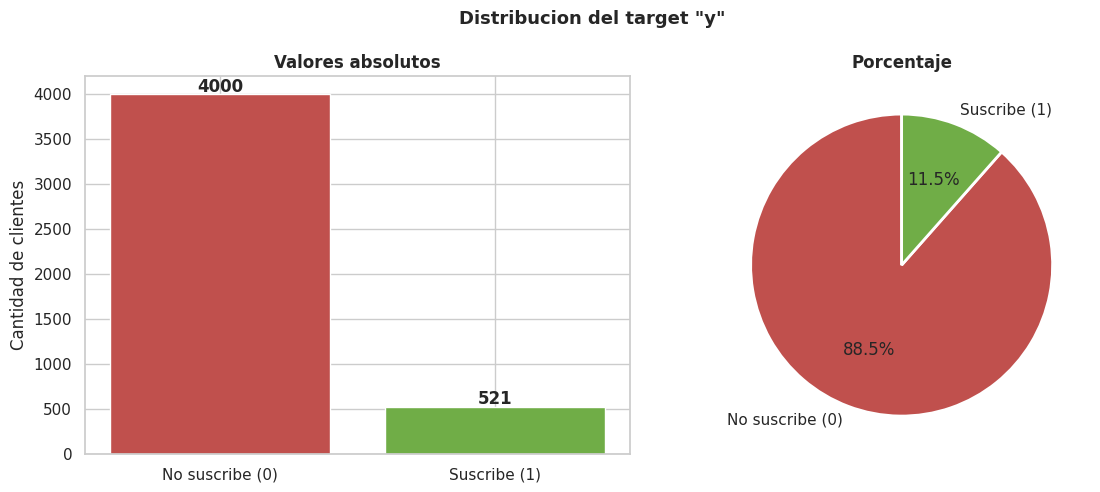

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#conteo
conteo = df_clean['y'].value_counts()
colores = ['#C0504D', '#70AD47']
axes[0].bar(['No suscribe (0)', 'Suscribe (1)'], conteo.values, color=colores, edgecolor='white')
axes[0].set_title('Valores absolutos', fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Porcentaje
pct = df_clean['y'].value_counts(normalize=True) * 100
axes[1].pie(pct.values, labels=['No suscribe (0)', 'Suscribe (1)'],
            colors=colores, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Porcentaje', fontweight='bold')

plt.suptitle('Distribucion del target "y"', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


>**Analisis**

Se observa claramente el desbalance de las clases. 4.000 clientes no suscribieron (88.5%) vs 521 que sí suscribieron (11.5%), casi 8 clientes que dicen "no" por cada 1 que dice "yes"

Al realizar el modelado las metricas mas importantes seran F1-score y REcall, para que el modelo sea capaz de detectar al 11.5% de clientes que si suscriben el deposito a plazos.


> ## <font color='#1890A3'>**Heatmap de Correlaciones variables numéricas**</font>

**Objetivo:** Ver todas las correlaciones entre todas las variables numericas del dataset con el target

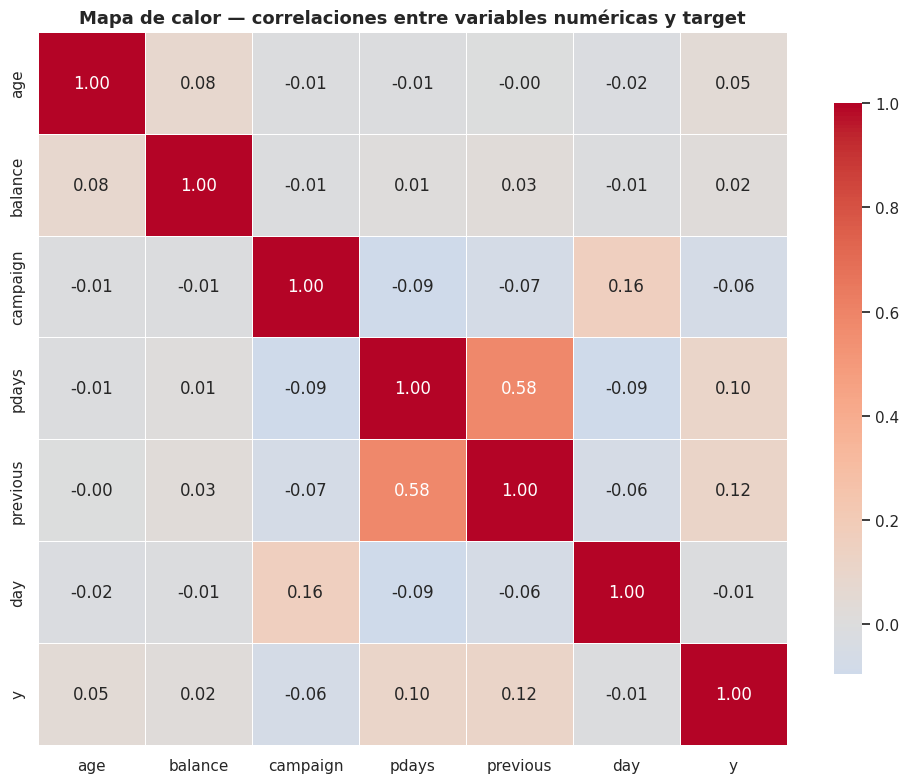

In [21]:
cols_num = ['age', 'balance', 'campaign', 'pdays', 'previous', 'day', 'y']
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_clean[cols_num].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar_kws={'shrink': 0.8},
            linewidths=0.5, linecolor='white')

ax.set_title('Mapa de calor — correlaciones entre variables numéricas y target', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


>**Analisis**

### Análisis de Correlación con `y`

| Nivel / Tipo | Variables | Analisis |
|:---|:---|:---|
| **Positiva baja** | `previous` (0.12), `pdays` (0.10)| Los clientes contactados antes y hace menos dias desde el ultimo contacto son un poco mas propensos a suscribir el deposito a plazos|
| **Positiva baja/nula** | `balance` (0.02)| Practicamente no aporta informacion lineal al modelo |
|**Negativa nula**|`campaign` (-0.06), `day` (-0.01)| mas llamadas se asocia a menos suscripciones (si se llama muchas veces es que el cliente no esta interesado, y day tampoco aporta info al modelo |

**Multicolenialidad moderada** entre:

`pdays` y `previous` = 0.58, es obvio ya que el que un cliente haya sido contactado en una campana anterior esta relacionado con los dias que han transcurrido desde la ultima llamada. Si fue contactado hay pdays, y sino lo fue pdays es 0.


**Todas las correlaciones son muy bajas, ninguna variable numérica por sí sola es suficiente para predecir la suscripción -> el poder predictivo está en las variables categóricas (poutcome, month, job)**

> ## <font color='#1890A3'>**Suscripcion por variable categorica**</font>

**Objetivo:** Ver las proporciones de suscripcion por variable categorica

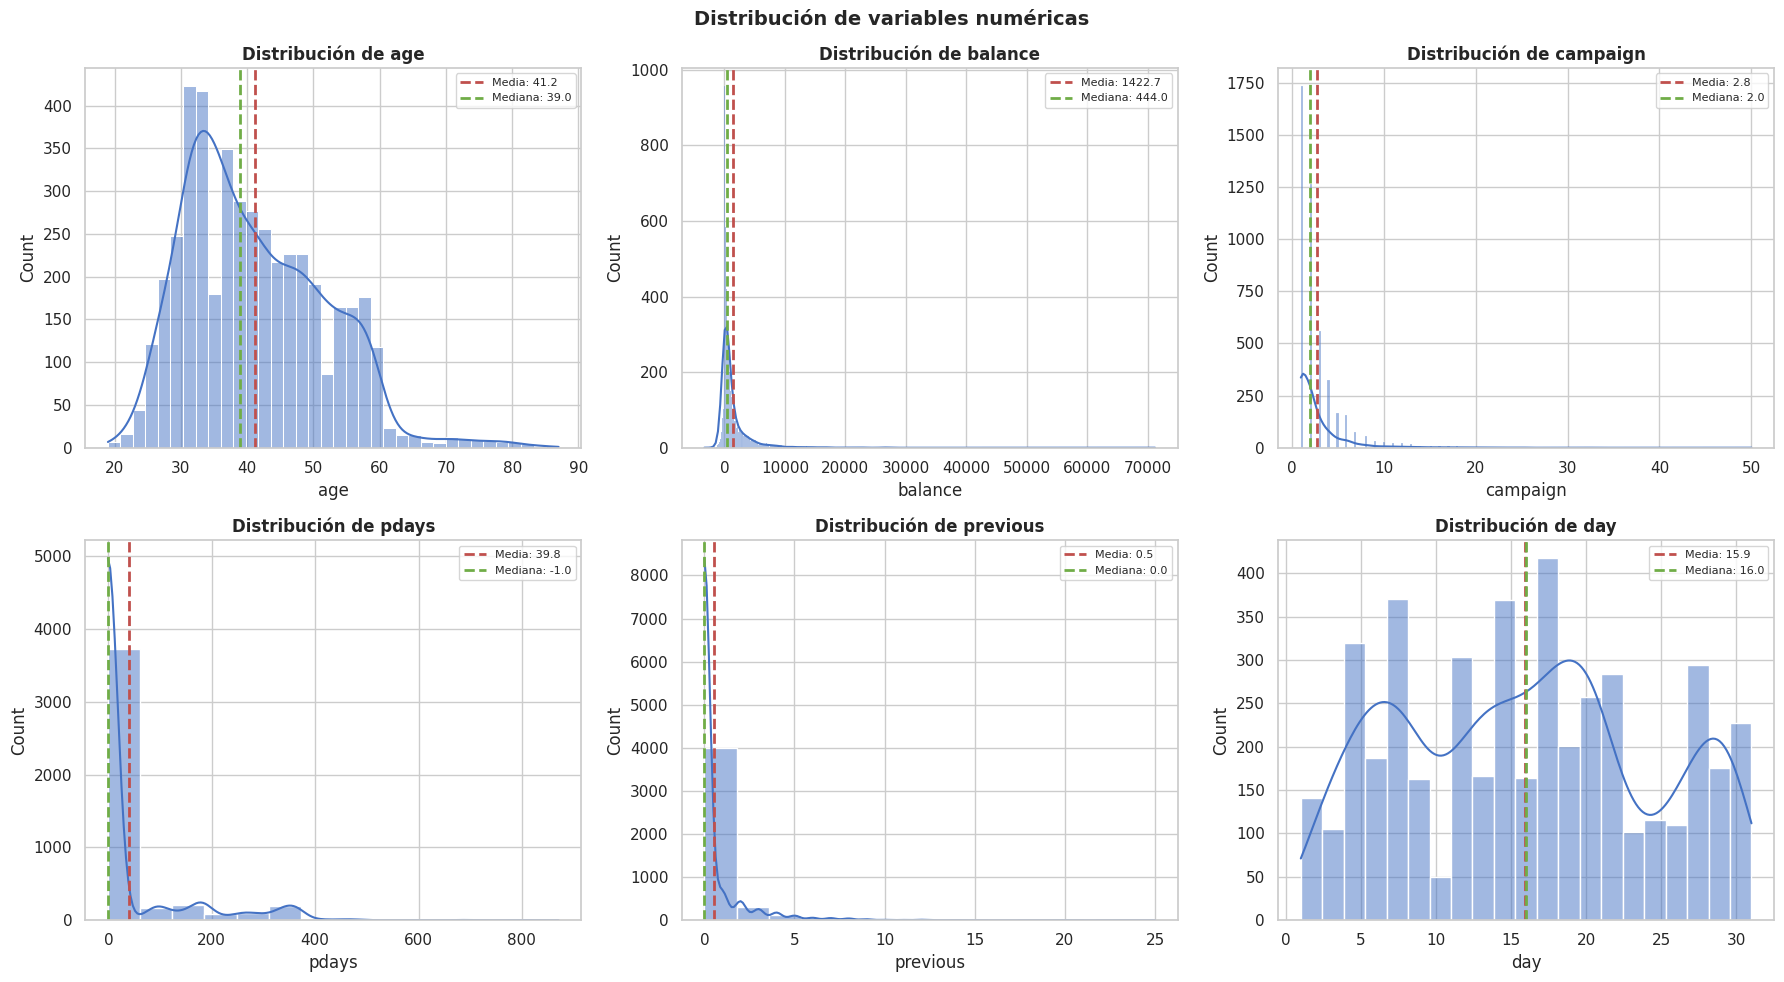

In [22]:
cols_num_dist = ['age', 'balance', 'campaign', 'pdays', 'previous', 'day']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), cols_num_dist):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='#4472C4', edgecolor='white')
    ax.axvline(df_clean[col].mean(),   color='#C0504D', linestyle='--',
               linewidth=2, label=f'Media: {df_clean[col].mean():.1f}')
    ax.axvline(df_clean[col].median(), color='#70AD47', linestyle='--',
               linewidth=2, label=f'Mediana: {df_clean[col].median():.1f}')
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

>**Analisis**

`age` con distribucion ligeramentee sesgada a la derecha con media (41.2) > mediana (39.0), y una cola un poco mas larga hacia los clientes de mayor edad. Aunque la distribucion no es exactamente normal tampoco es totalmente opuesta, se utilizara StandardScaler.

`balance` tiene una media (1.422) >> mediana (444), muy sesgada a la derecha con una larga cola aplastada hasta los 70.000 usd que afectan los valores de la media. Se utilizara MinMaxScaler.

`campaign` con media (2.8) > mediana (2.0), con la mayoria de los valores concenetrados en 1 a 3 contactos y luego una larga cola  que va disminuyendo y aplastandose hasta el 50. Se utlizara MinMaxScaler

`pdays` tiene media (39.8) >> mediana (-1.0), con el -1 concnentrando casi toda la distribución, la media es 39.8 por los valores reales. Esta variable mezcla dos cosas: 1) si la persona fue contactada o no, y 2) si fue contactada, hace cuanto tiempo.
Conviene convertirla en dos variables, una para saber si fue o no contactado el cliente, y otra para ver el numero de dias desde que fue contactado (en el caso de que no haya sido contactado tendria un valor de cero) y luego aplicar MinMaxScaler.

`previous` con media (0.5) > mediana (0.0), la distribucion esta dominada por ceros y luego va formandose una cola aplastada a la derecha hasta el valor de 25. Se utilizara MinMaxScaler.

`day` tiene una distribucion mas uniforme con media (15.9) casi igual a la  mediana (16.0), con la distribucion oscilando entre los valoes de 0 al 30. Se aplicara MinMaxScaler.

# <font color='#1890A3'> **SECCION 4 PREPROCESAMIENTO DE DATOS**
**Categorias|Train/Test | Escalamiento** </font>

Aunque en clases vimos que los modelos de clasificacion no son sensibles al escalado, revisando la documentacion de SVM en stickit learn dice: ***""Support Vector Machine algorithms are not scale invariant, so it is highly recommended to scale your data. For example, scale each attribute on the input vector X to [0,1] or [-1,+1], or standardize it to have mean 0 and variance 1."***

Anteriormente hemos trabajado con StandardScaler y MaxMinScaler, y la evaluacion del grafico anterior se evaluaron esas opciones, sin embargo, se reviso la documentacion en la parte de pre procesamiento debido a que varias distribuciones presentan una cola larga (outliers) y para validar que los escaladores sean correctos encontrandose los siguiente: ***"if some outliers are present in the set, robust scalers or other transformers can be more appropriate."***, que esta basado en el IQR y la mediana por lo que para este caso, los escaladores que se utilizaran seran:


**StandardScaler** para `age`
**MinMaxScaler** para `days`
**RobustScaler** para el resto

> ## <font color='#1890A3'>**4.1 Feature Engineering**</font>

Transformacion de `pdays`:
- crear variable `contacted_before` binaria (yes =1, no = 0)
- reemplazar -1 en pdays por 0

**Justificacion** `pdays` tiene dos tipos de información mezcladas en una sola columna:
- **-1** indicando que el cliente nunca fue contactado en una campaña anterior
- **1 a 871**  días transcurridos desde el último contacto de campaña anterior
si mantengo valores negativos y positivos en una columna numerica, elmodelo va a interpretar el -1 como menos dias, o un dia antes(imposible).. y lo que significa es que no ha sido contactado.


In [23]:
# variable binaria ¿cliente fue contactado en campaña anterior?
df_clean['contacted_before'] = (df_clean['pdays'] != -1).astype(int)

# Reemplazar -1 por 0 en pdays
df_clean['pdays'] = df_clean['pdays'].replace(-1, 0)

print(df_clean['contacted_before'].value_counts())
print()
print('pdays sin -1:')
print(f'  Mínimo: {df_clean["pdays"].min()}')
print(f'  Valores distintos de 0: {(df_clean["pdays"] != 0).sum()}')
print()
print(f'Shape: {df_clean.shape}')

contacted_before
0    3705
1     816
Name: count, dtype: int64

pdays sin -1:
  Mínimo: 0
  Valores distintos de 0: 816

Shape: (4521, 17)


> ## <font color='#1890A3'>**4.2 Codificación de variables categóricas y escalado numérico**</font>


In [29]:
# Numérica con StandardScaler
cols_standard = ['age']

# Numéricas con RobustScaler
cols_robust = ['balance', 'campaign', 'pdays', 'previous']

# Numéricas con MinMaxScaler
cols_minmax = ['day']

# Categórica con OrdinalEncoder
cols_ordinal = ['education']

# Categóricas con OneHotEncoder
cols_onehot = ['job', 'marital', 'contact', 'month', 'poutcome']

# Binarias ya codificadas
cols_binarias = ['default', 'housing', 'loan', 'contacted_before']

print('StandardScaler :', cols_standard)
print('RobustScaler   :', cols_robust)
print('MinMaxScaler   :', cols_minmax)

print('OrdinalEncoder :', cols_ordinal)
print('OneHotEncoder  :', cols_onehot)
print('Ya codificadas :', cols_binarias)


StandardScaler : ['age']
RobustScaler   : ['balance', 'campaign', 'pdays', 'previous']
MinMaxScaler   : ['day']
OrdinalEncoder : ['education']
OneHotEncoder  : ['job', 'marital', 'contact', 'month', 'poutcome']
Ya codificadas : ['default', 'housing', 'loan', 'contacted_before']


In [31]:
preprocesador = ColumnTransformer([
    ('standard', StandardScaler(), cols_standard),
    ('robust',   RobustScaler(),   cols_robust),
    ('minmax',   MinMaxScaler(),   cols_minmax),
    ('ordinal',  OrdinalEncoder(categories=[['primary', 'secondary', 'tertiary']]),
                 cols_ordinal),
    ('onehot',   OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                 cols_onehot),
    ('binarias', 'passthrough',    cols_binarias)
],
remainder='drop'
)

print('Preprocesador definido correctamente')


Preprocesador definido correctamente


> ## <font color='#1890A3'>**4.3 Split Estratificado**</font>
El stratify=y es fundamental por el desbalance de las clases del target (solo 521 casos positivos)


In [32]:
X = df_clean.drop(columns=['y'])
y = df_clean['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print()
print('Proporción del target en cada conjunto:')
print(f'  Train → no: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)  |  yes: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'  Test  → no: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)  |  yes: {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')

X_train: (3616, 16) | X_test: (905, 16)

Proporción del target en cada conjunto:
  Train → no: 3199 (88.5%)  |  yes: 417 (11.5%)
  Test  → no: 801 (88.5%)  |  yes: 104 (11.5%)


> ## <font color='#1890A3'>**4.4 Preprocesasor**</font>

In [33]:
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep  = preprocesador.transform(X_test)

print(f'X_train antes: {X_train.shape} → después: {X_train_prep.shape}')
print(f'X_test  antes: {X_test.shape}  → después: {X_test_prep.shape}')

X_train antes: (3616, 16) → después: (3616, 43)
X_test  antes: (905, 16)  → después: (905, 43)


# <font color='#1890A3'> **SECCION 5  ENTRENAMIENTO Y EVALUACION DE MODELOS**
**DecisionTree|SVM** </font>

> ## <font color='#1890A3'>**5.1 DecisionTree**</font>

In [34]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_prep, y_train)
y_pred_dt = dt.predict(X_test_prep)

print('=== Decision Tree — Métricas en Test ===')
print()
print(f'Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dt):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_dt):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_dt):.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['No suscribe', 'Suscribe']))

=== Decision Tree — Métricas en Test ===

Accuracy : 0.8155
Precision: 0.2353
Recall   : 0.2692
F1-score : 0.2511

              precision    recall  f1-score   support

 No suscribe       0.90      0.89      0.89       801
    Suscribe       0.24      0.27      0.25       104

    accuracy                           0.82       905
   macro avg       0.57      0.58      0.57       905
weighted avg       0.83      0.82      0.82       905



El valor de Accuracy es alto (0.8155) pero las clases estan desbalanceadas asi que esta metrica no es relevante.

Recall (0.2692) indicando que el modelo solo detecta el 27% de los clientes que sí suscriben y un F1 ( 0.2511) demuestra que el modelo es debil para detectar los clientes que si suscriben.

El Decision Tree está sesgado hacia la clase mayoritaria (clientes que no suscriben)

> ## <font color='#1890A3'>**5.2 SVM**</font>

In [35]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_prep, y_train)

y_pred_svm = svm.predict(X_test_prep)

print('=== SVM — Métricas en Test ===')
print()
print(f'Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_svm):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_svm):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_svm):.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['No suscribe', 'Suscribe']))

=== SVM — Métricas en Test ===

Accuracy : 0.8829
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

              precision    recall  f1-score   support

 No suscribe       0.88      1.00      0.94       801
    Suscribe       0.00      0.00      0.00       104

    accuracy                           0.88       905
   macro avg       0.44      0.50      0.47       905
weighted avg       0.78      0.88      0.83       905



El modelo con Accuracy (0.8829) que coincide exactamente con el 88.5% de los clientes que no suscriben no aprendió nada.
Precision, Recall y F1 igual a cero indica que no detecto ni un cliente que suscribio.

SVM por defecto trata ambas clases con igual peso, y con 88.5% de "no" vs 11.5% de "yes", el modelo aprende que predecir siempre "no".

Es necesario colocar en el modelo c**lass_weight='balanced'**

In [36]:
svm_balanced = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)
svm_balanced.fit(X_train_prep, y_train)

y_pred_svm = svm_balanced.predict(X_test_prep)

print('=== SVM con class_weight=balanced — Métricas en Test ===')
print()
print(f'Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_svm):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_svm):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_svm):.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['No suscribe', 'Suscribe']))

=== SVM con class_weight=balanced — Métricas en Test ===

Accuracy : 0.8398
Precision: 0.2929
Recall   : 0.2788
F1-score : 0.2857

              precision    recall  f1-score   support

 No suscribe       0.91      0.91      0.91       801
    Suscribe       0.29      0.28      0.29       104

    accuracy                           0.84       905
   macro avg       0.60      0.60      0.60       905
weighted avg       0.84      0.84      0.84       905



Ahora funciona mejor el modelo, mantiene el Accuracy alto (0.839) y el Recall (0.278) y F1 (0.2857) indicando que aun el modelo tiene dificultad para detectar a los clientes que si suscribieron.

SVM tiene las metricas un poco mejor que el DecisionTree aunque ambos tienen REcall y F1 bajas. Se probara el tunning a ver si mejoran los resultados

> ## <font color='#1890A3'>**5.3 Optimizacion con gridsearcCV**</font>

In [37]:
# Gridsearch para DecisionTree
param_grid_dt = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_leaf' : [1, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'class_weight'     : ['balanced', None]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train_prep, y_train)

print(f'Mejores hiperparámetros: {grid_dt.best_params_}')
print(f'Mejor F1 en CV: {grid_dt.best_score_:.4f}')
print()

y_pred_dt_tuned = grid_dt.predict(X_test_prep)

print('=== Decision Tree Tuneado — Métricas en Test ===')
print()
print(f'Accuracy : {accuracy_score(y_test, y_pred_dt_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dt_tuned):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_dt_tuned):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_dt_tuned):.4f}')
print()
print(classification_report(y_test, y_pred_dt_tuned, target_names=['No suscribe', 'Suscribe']))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}
Mejor F1 en CV: 0.3321

=== Decision Tree Tuneado — Métricas en Test ===

Accuracy : 0.8729
Precision: 0.4225
Recall   : 0.2885
F1-score : 0.3429

              precision    recall  f1-score   support

 No suscribe       0.91      0.95      0.93       801
    Suscribe       0.42      0.29      0.34       104

    accuracy                           0.87       905
   macro avg       0.67      0.62      0.64       905
weighted avg       0.86      0.87      0.86       905



La precision casi se duplicó (0.23 a 0.42), el modelo ahora acierta en 42 de cada 100 predicciones positivas, sin embargo
Recall mejoró solo un poco (0.27 a 0.29) siguiendo sin identificarse el 71% de los clientes que suscriben.

F1 (0.25 a 0.34) mejora un poco pero aun no discrimina tan bien entre las clases.


In [40]:
# GridSearchCV para SVM
param_grid_svm = {
    'C'           : [0.01, 0.1, 1, 10],
    'kernel'      : ['rbf'],
    'gamma'       : ['scale', 0.01, 0.001],
    'class_weight': ['balanced']
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_prep, y_train)

print(f'Mejores hiperparámetros: {grid_svm.best_params_}')
print(f'Mejor F1 en CV: {grid_svm.best_score_:.4f}')
print()

y_pred_svm_tuned = grid_svm.predict(X_test_prep)

print('=== SVM Tuneado — Métricas en Test ===')
print()
print(f'Accuracy : {accuracy_score(y_test, y_pred_svm_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_svm_tuned):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_svm_tuned):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_svm_tuned):.4f}')
print()
print(classification_report(y_test, y_pred_svm_tuned, target_names=['No suscribe', 'Suscribe']))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
Mejor F1 en CV: 0.3321

=== SVM Tuneado — Métricas en Test ===

Accuracy : 0.7901
Precision: 0.2737
Recall   : 0.5000
F1-score : 0.3537

              precision    recall  f1-score   support

 No suscribe       0.93      0.83      0.87       801
    Suscribe       0.27      0.50      0.35       104

    accuracy                           0.79       905
   macro avg       0.60      0.66      0.61       905
weighted avg       0.85      0.79      0.81       905



El SVM tuneado genera mejores resultados, incrmeentando bastante el Recall (0.26 a 0.50) pero el  F1 se mantiene casi igual



In [41]:
resultados = pd.DataFrame([
    {
        'Modelo'   : 'Decision Tree Base',
        'Accuracy' : accuracy_score(y_test, y_pred_dt),
        'Precision': precision_score(y_test, y_pred_dt),
        'Recall'   : recall_score(y_test, y_pred_dt),
        'F1-score' : f1_score(y_test, y_pred_dt)
    },
    {
        'Modelo'   : 'Decision Tree Tuneado',
        'Accuracy' : accuracy_score(y_test, y_pred_dt_tuned),
        'Precision': precision_score(y_test, y_pred_dt_tuned),
        'Recall'   : recall_score(y_test, y_pred_dt_tuned),
        'F1-score' : f1_score(y_test, y_pred_dt_tuned)
    },
    {
        'Modelo'   : 'SVM Base',
        'Accuracy' : accuracy_score(y_test, y_pred_svm),
        'Precision': precision_score(y_test, y_pred_svm),
        'Recall'   : recall_score(y_test, y_pred_svm),
        'F1-score' : f1_score(y_test, y_pred_svm)
    },
    {
        'Modelo'   : 'SVM Tuneado',
        'Accuracy' : accuracy_score(y_test, y_pred_svm_tuned),
        'Precision': precision_score(y_test, y_pred_svm_tuned),
        'Recall'   : recall_score(y_test, y_pred_svm_tuned),
        'F1-score' : f1_score(y_test, y_pred_svm_tuned)
    }
]).set_index('Modelo').round(4)

print('=== Tabla Comparativa de Modelos ===')
print()
print(resultados)
print()

# Identificar el mejor modelo por F1
mejor = resultados['F1-score'].idxmax()
print(f'Mejor modelo por F1-score: {mejor} ({resultados.loc[mejor, "F1-score"]:.4f})')
mejor_recall = resultados['Recall'].idxmax()
print(f'Mejor modelo por Recall  : {mejor_recall} ({resultados.loc[mejor_recall, "Recall"]:.4f})')

=== Tabla Comparativa de Modelos ===

                       Accuracy  Precision  Recall  F1-score
Modelo                                                      
Decision Tree Base       0.8155     0.2353  0.2692    0.2511
Decision Tree Tuneado    0.8729     0.4225  0.2885    0.3429
SVM Base                 0.8398     0.2929  0.2788    0.2857
SVM Tuneado              0.7901     0.2737  0.5000    0.3537

Mejor modelo por F1-score: SVM Tuneado (0.3537)
Mejor modelo por Recall  : SVM Tuneado (0.5000)


Para DecisionTree el tuning mejoro la Precision (0.24 a 0.42) pero el Recallse mantuvo casi igual (0.27 → 0.29). Se mejora la seleccion entre las clases pero aun se quedan sin detectar a la mayoría de los clientes que suscriben

Con el SVM, el tuning hizo lo contrario, la Precisi bajó un poco (0.29 a 0.27) pero el Recall subio bastante (0.28 a 0.50): el modelo pasó de detectar 29 de cada 100 clientes que suscriben a detectar 50 y el F1 paso de 0.29 a 0.37 incrementandose la capacidad de discriminar entre suscritos y no suscritos.

El modelo con mejores resultados es el SVM Tuneado

##<font color='#1890A3'>**5.4 Evaluacion del Modelo con los  nuevos hiperparametros**</font>

In [42]:
y_pred_final  = grid_svm.predict(X_test_prep)

metricas_final = {
    'Accuracy' : accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall'   : recall_score(y_test, y_pred_final),
    'F1-score' : f1_score(y_test, y_pred_final)
}

print('=== Evaluación Final — SVM Tuneado ===')
print()
for metrica, valor in metricas_final.items():
    print(f'{metrica:10s}: {valor:.4f}')
print()
print(classification_report(y_test, y_pred_final,
      target_names=['No suscribe', 'Suscribe']))

=== Evaluación Final — SVM Tuneado ===

Accuracy  : 0.7901
Precision : 0.2737
Recall    : 0.5000
F1-score  : 0.3537

              precision    recall  f1-score   support

 No suscribe       0.93      0.83      0.87       801
    Suscribe       0.27      0.50      0.35       104

    accuracy                           0.79       905
   macro avg       0.60      0.66      0.61       905
weighted avg       0.85      0.79      0.81       905



> ## <font color='#1890A3'>**5.5 Visualizacion de Compracion de metricas**</font>

> ## <font color='#1890A3'>**Matriz de Confusion del Modelo Optimizado**</font>

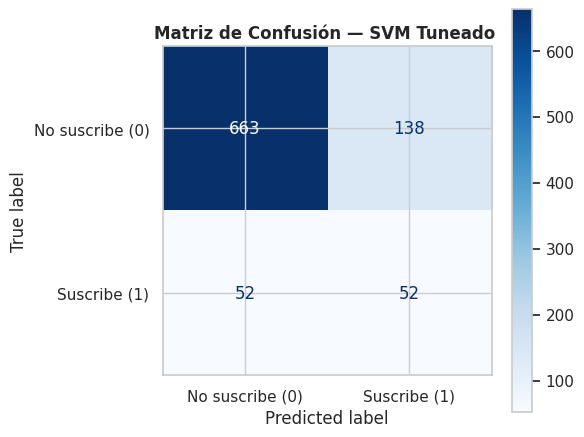

In [43]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['No suscribe (0)', 'Suscribe (1)'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusión — SVM Tuneado ',
             fontweight='bold')
plt.tight_layout()
plt.show()

>**Analisis**

El modelo predice correctamente a 663 clientes que NO suscriben el deposito a plazos, y a 52 clientes que SI lo suscriben.

Ademas detecta a 138 Falsos Positivos (clientes que NO suscriben pero el modelo predice que sí) y a 52 Falsos negativos (clientes que SI suscriben pero el modelo dice que no.
En terminos del negocio, se llaman a 138 personas que no van a suscribir el deposito a plazos y no se llamarian a 52 que si se suscribirian osea perderia a 52 clientes.



> ## <font color='#1890A3'>**Curva ROC-AUC**</font>

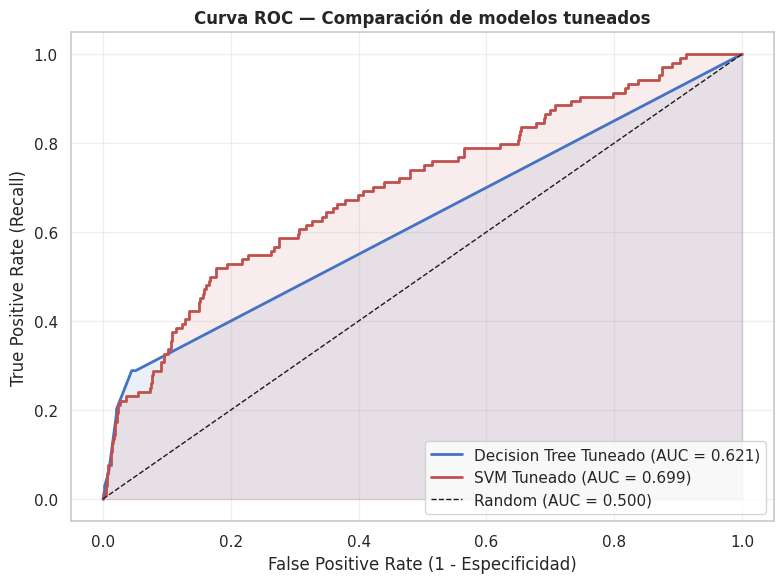

In [47]:
dt_proba  = grid_dt.predict_proba(X_test_prep)[:, 1]
svm_scores = grid_svm.decision_function(X_test_prep)

fpr_dt,  tpr_dt,  _ = roc_curve(y_test, dt_proba)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)

auc_dt  = roc_auc_score(y_test, dt_proba)
auc_svm = roc_auc_score(y_test, svm_scores)


fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_dt,  tpr_dt,  linewidth=2, color='#4472C4', label=f'Decision Tree Tuneado (AUC = {auc_dt:.3f})')
ax.plot(fpr_svm, tpr_svm, linewidth=2, color='#C0504D', label=f'SVM Tuneado (AUC = {auc_svm:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')

ax.fill_between(fpr_dt,  tpr_dt,  alpha=0.1, color='#4472C4')
ax.fill_between(fpr_svm, tpr_svm, alpha=0.1, color='#C0504D')

ax.set_xlabel('False Positive Rate (1 - Especificidad)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Curva ROC — Comparación de modelos tuneados', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


>**Analisis**

SVM Tuneado: 0.699
Decision Tree Tuneado: 0.621

Los dos modelos superan el random, pero utilizando el modelo SVM tuneado hay 69.9% de probabilidad de clasificar corretamente un cliente que suscribe sobre uno que no suscribe.

La curva del SVm esta por encima de la del DecisionTree en todo el grafico, osea que es mejor en todo el rango


## Conclusiones y Hallazgos

**Perfil del cliente que suscribe:**
- Los clientes jubilados (23.5%) y estudiantes (22.6%) tienen la mayor tasa de suscripción. El banco debería priorizar estos segmentos en futuras campañas.
- A mayor nivel educativo, mayor probabilidad de suscribir. Clientes con educación terciaria suscriben a una tasa de 14.3% vs 9.4% en educación primaria.
- Clientes solteros y divorciados suscriben más que los casados, probablemente porque tienen menos compromisos financieros compartidos.

**Importancia del historial:**
- Si un cliente suscribió en una campaña anterior (poutcome=success), tiene un 64.3%  de probabilidad de volver a suscribir. Es el predictor más poderoso del dataset. El banco debería mantener y priorizar una base de datos actualizada de clientes con historial positivo.

**Mes en el que se realiza la llamada:**
- Octubre (46.2%), diciembre (45.0%) y marzo (42.9%) son los meses con mayor tasa suscripciones. Mayo, el mes con más llamadas del dataset, tiene la peor tasa (6.7%). El banco debe concentrar las campañas en el último trimestre y en marzo podría mejorar significativamente los resultados sin aumentar el presupuesto.

**Variables con bajo poder predictivo:**
- El balance promedio anual y el día del mes del contacto tienen correlaciones prácticamente nulas con la suscripción. Estos datos, aunque disponibles, no deberían ser criterios de segmentación para las campañas.

---

### Resultados de los modelos

| Modelo | Accuracy | Precision | Recall | F1-score |
|---|---|---|---|---|
| Decision Tree Base | 0.8155 | 0.2353 | 0.2692 | 0.2511 |
| Decision Tree Tuneado | 0.8729 | 0.4225 | 0.2885 | 0.3429 |
| SVM Base | 0.8398 | 0.2929 | 0.2788 | 0.2857 |
| SVM Tuneado | 0.7901 | 0.2737 | 0.5000 | 0.3537 |

---

### Modelo recomendado: SVM Tuneado

El SVM Tuneado es el modelo más adecuado para este problema con los datos disponibles por las siguientes razones:

**Mejor Recall (0.50):** el modelo detecta la mitad de los clientes que van a suscribir. Sin modelo, el banco necesita llamar a todos los clientes para encontrarlos. Con el modelo, puede priorizar una lista reducida y capturar la mitad de las oportunidades con menos recursos.

**AUC de 0.699:** el modelo tiene un 70% de probabilidad de distinguir correctamente entre un cliente que suscribe y uno que no. Esto es significativamente mejor que una selección aleatoria de clientes (50%).

**Falsos Positivos** el modelo genera 138 llamadas innecesarias por cada 52 suscripciones reales capturadas. En el sector bancario, el costo de una llamada telefónica es marginal comparado con el valor de un depósito a plazo captado.

---

### Limitaciones del modelo

**Desbalance:** con solo 11.5% de casos positivos, ningún modelo alcanza métricas altas en la clase minoritaria . El Recall de 0.50 es el límite razonable con los algoritmos disponibles y el dataset actual.

**Variables eliminadas:** la duración de la llamada fue eliminada por data leakage. En producción real, esta variable no está disponible antes de hacer la llamada, su exclusión es correcta aunque reduce el poder predictivo del modelo.

**Vigencia de los datos:** el dataset corresponde a campañas de 2008-2010. Los patrones de comportamiento financiero de los clientes pueden haber cambiado significativamente, especialmente en el uso de canales digitales. El modelo debería reentrenarse con datos recientes antes de desplegarse en producción.

---

### Recomendaciones para el banco

1. Recontactar prioritariamente a clientes con historial de suscripción exitosa en campañas anteriores ya que tienen 6 veces más probabilidad de suscribir.
2. Concentrar las campañas en octubre, diciembre y marzo, evitando mayo y julio.
3. Enfocar los esfuerzos en segmentos de jubilados, estudiantes y clientes con educación terciaria.
4. Limitar el número de contactos por cliente — más de 3 llamadas sin respuesta positiva tiene rendimientos decrecientes según los datos.
5. Implementar el modelo SVM como herramienta de priorización de llamadas, no como reemplazo del criterio del ejecutivo comercial.